In [1]:
import keras
import tensorflow as tf
import numpy as np
from pprint import pprint
import plot
from sklearn.metrics import classification_report

2025-02-09 18:23:07.362341: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739118187.519603   24688 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739118187.565469   24688 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-09 18:23:07.918970: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
model = keras.models.load_model("model.keras")
# X_train_stratified = np.load("X_train_stratified.npy")
# y_train_stratified = np.load("y_train_stratified.npy")
X_test_stratified = np.load("X_test_stratified.npy")
y_test_stratified = np.load("y_test_stratified.npy")

I0000 00:00:1739118193.193438   24688 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5556 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6


In [3]:
labels = [
        "cs",
        "econ",
        "eess",
        "math",
        "physics",
        "q-bio",
        "q-fin",
        "stat",
    ]

In [4]:
sub_model = tf.keras.Sequential(model.layers[:4])

In [5]:
logits = sub_model.predict(X_test_stratified)
temprature = 1
new_logits = logits / temprature
y_preds = np.array([tf.nn.softmax(l) for l in new_logits])
pprint(y_preds)

I0000 00:00:1739118200.307566   26516 service.cc:148] XLA service 0x7f731c004660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1739118200.307803   26516 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6
2025-02-09 18:23:20.332730: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1739118200.388997   26516 cuda_dnn.cc:529] Loaded cuDNN version 90300


 138/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

I0000 00:00:1739118201.929846   26516 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
array([[8.70382041e-03, 8.03262374e-05, 3.81798018e-04, ...,
        7.04234990e-04, 1.07941299e-03, 1.24458643e-03],
       [1.83183607e-02, 2.64019123e-04, 1.16430724e-03, ...,
        2.14515370e-03, 1.65433786e-03, 5.10313502e-03],
       [3.93668393e-04, 1.55332009e-06, 1.16392024e-04, ...,
        1.14651149e-04, 1.13886636e-05, 2.56562835e-05],
       ...,
       [3.43538763e-04, 5.00957185e-06, 4.16693256e-05, ...,
        1.88318343e-04, 5.26224940e-05, 6.21157160e-05],
       [3.20851244e-03, 1.42639241e-04, 7.90476683e-04, ...,
        2.77943071e-03, 4.07451182e-04, 8.46779963e-04],
       [2.07863172e-06, 2.45381617e-08, 4.19113206e-07, ...,
        5.14180419e-06, 2.71837223e-07, 5.30825332e-07]], dtype=float32)


In [10]:
for i in range(len(y_test_stratified)):
  if y_test_stratified[i].sum() > 1:
    print(i)
    print(y_test_stratified[i])
    print(y_preds[i])

8
[0 0 0 0 1 1 0 0]
[0.07472174 0.00092299 0.01092949 0.04842298 0.84515244 0.00833045
 0.00249673 0.00902309]
9
[0 0 0 1 1 0 0 0]
[2.0570194e-02 1.8732865e-04 2.3296513e-03 8.2163818e-02 8.8856077e-01
 2.2344103e-03 8.5265265e-04 3.1012159e-03]
10
[1 0 1 0 0 0 0 0]
[9.95970607e-01 6.86917847e-05 1.17108203e-03 1.20131815e-04
 9.37930745e-05 3.87664157e-04 2.46308133e-04 1.94173807e-03]
42
[1 0 0 1 0 0 0 0]
[0.3768721  0.00560006 0.06525078 0.14492466 0.29412553 0.04371024
 0.00761295 0.06190371]
47
[0 0 0 0 1 1 0 0]
[0.3835117  0.0085704  0.0398049  0.08836553 0.3635094  0.04685726
 0.01131274 0.05806809]
49
[1 0 0 1 0 0 0 1]
[0.31227446 0.00171673 0.01379317 0.5964823  0.02644034 0.00638453
 0.00569675 0.03721178]
50
[1 0 1 0 0 0 0 0]
[0.08365459 0.001426   0.02064116 0.05349777 0.80903506 0.01595196
 0.002335   0.01345849]
60
[0 0 0 1 1 0 0 0]
[1.3024100e-02 2.2103055e-04 1.1275779e-03 5.3853840e-01 4.4063300e-01
 1.6668494e-03 1.2381304e-03 3.5509095e-03]
70
[0 0 0 1 0 0 0 1]
[0.29

In [11]:
i = 8
print(y_test_stratified[i])
print(y_preds[i])

[0 0 0 0 1 1 0 0]
[0.07472174 0.00092299 0.01092949 0.04842298 0.84515244 0.00833045
 0.00249673 0.00902309]


In [12]:
y_pred_bin = (y_preds > 0.05).astype(int)

In [15]:
print(classification_report(y_test_stratified, y_pred_bin))

              precision    recall  f1-score   support

           0       0.61      0.96      0.75     26779
           1       0.00      0.00      0.00       428
           2       0.22      0.19      0.20      3686
           3       0.53      0.92      0.67     25538
           4       0.73      0.98      0.84     54739
           5       0.21      0.20      0.20      1814
           6       0.16      0.03      0.05       787
           7       0.19      0.30      0.23      4770

   micro avg       0.61      0.89      0.72    118541
   macro avg       0.33      0.45      0.37    118541
weighted avg       0.61      0.89      0.72    118541
 samples avg       0.75      0.93      0.79    118541



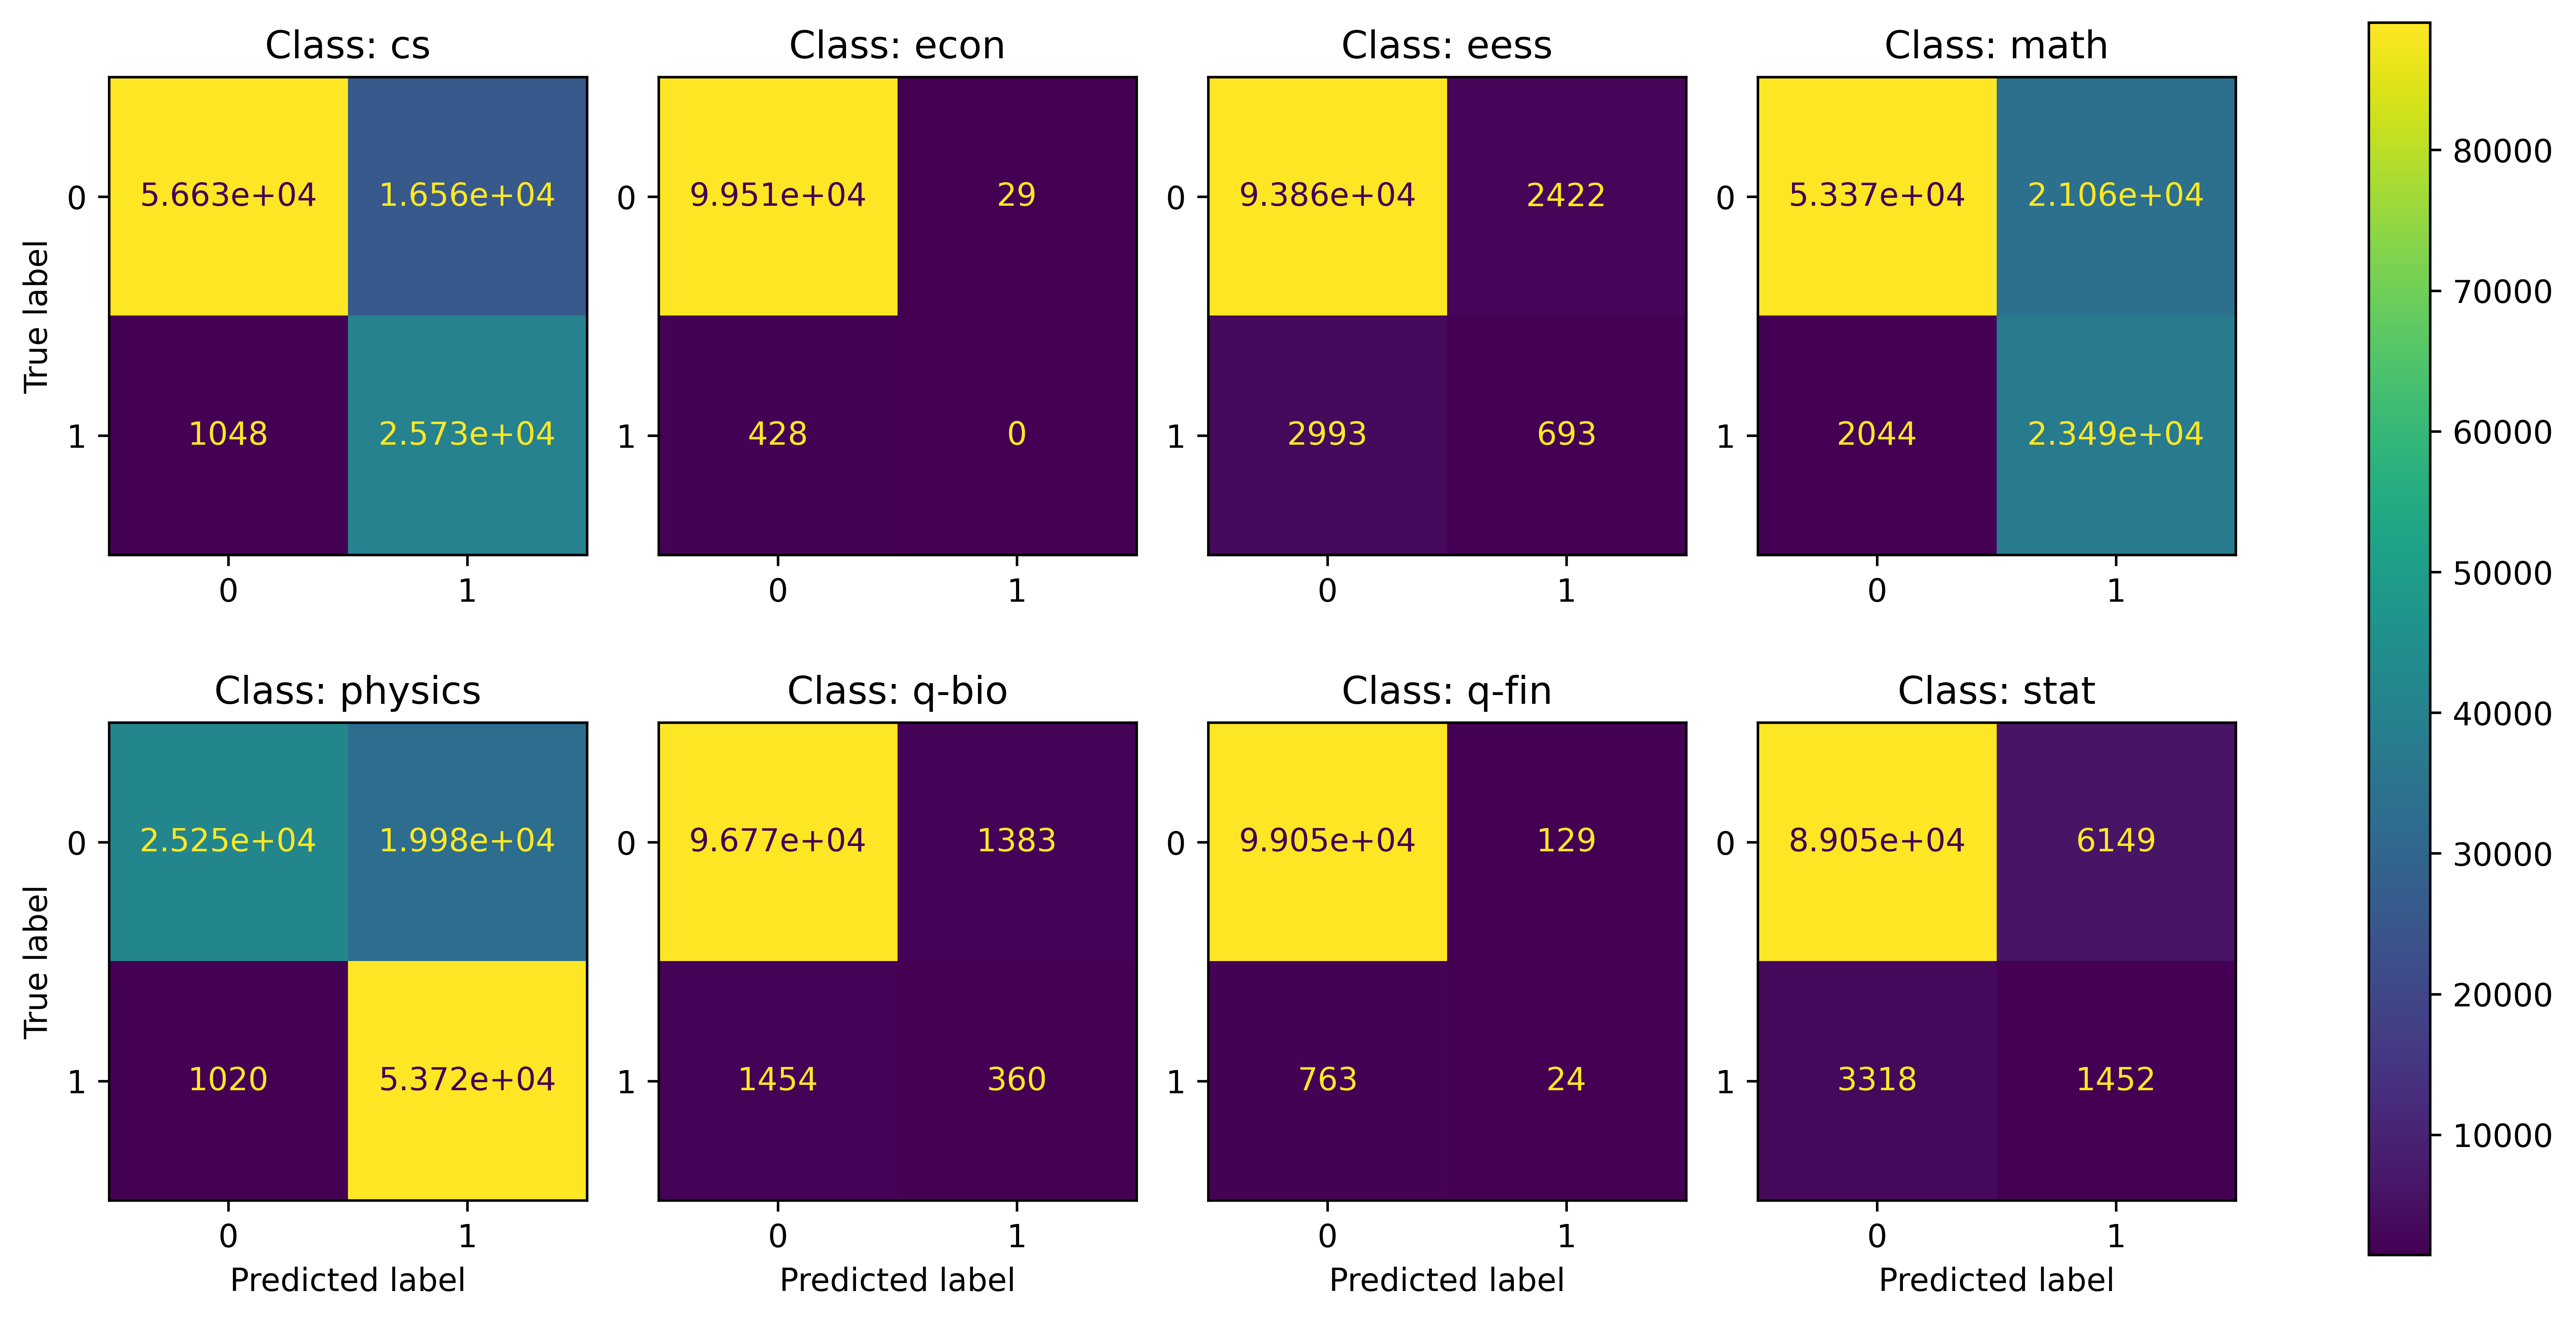

<Figure size 640x480 with 0 Axes>

In [16]:
plot.plot_confusion_matrix(y_test_stratified, y_pred_bin)
# plot.plot_micro_average_precision(y_test_stratified, y_preds)